# Alumnos:

* ### Vázquez Martínez Fredin Alberto

# Aplicación: StudyBuddy
Aplicación que con base en tus notas de clase y documentos relacionados te ayuda a estudiar para pasar tu examen final.

## Desarrollo

### Input:
Se va a considerar un agente con langchain capaz de leer notas, la entrada esperada serán Pdfs, posteriormente va captar información.


### Output:
La salida esperada será un resumen de puntos más importantes de tus notas.

En caso que el usuario incluya alguna de los siguientes puntos, se va esperar resultados adicionales:

1. Palabras clave o temas clave: además del resumen general, el agente será capaz de poder enfocar el resumen de las notas para ese tema solicitado por el usuario. 

2. Preguntas: el agente tendrá la capacidad de responder a preguntas en base a las notas dadas.

In [58]:
## Instalando las dependencias ##
# !pip install langchain_ollama
# !pip install langchain_community
# !pip install pymupdf
# !pip install langchain_text_splitters
# !pip install langchain_chroma
!pip install langgraph

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


In [59]:
## Cargando las librerias ##
import os 
from rich import print as rprint
from rich.rule import Rule
from langchain_ollama.chat_models import ChatOllama
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from IPython.display import Markdown, display
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


# loaders
from langchain_community.document_loaders import WebBaseLoader, PyMuPDFLoader, UnstructuredPDFLoader

# langGraph
from langgraph.graph import MessagesState, StateGraph
from IPython.display import Image, display
from langgraph.graph import START, StateGraph

### Cargando el modelo y definiendo loaders para recuperación de información

In [22]:
## Cargando el modelo ##
MODEL = "llama3.2"
llm = ChatOllama(model=MODEL)

## Definiendo loaders ##

name_dir = './pdfs_notes'
documents = [
    doc
    for file in os.listdir(name_dir)
    if file.endswith(".pdf")
    for doc in PyMuPDFLoader(os.path.join(name_dir, file)).load()
]

rprint(f"Total documents {len(documents)}")
for i, doc in enumerate(documents[:3], start=1):
    rprint(Rule(f"Doc {i}"))
    rprint(doc.page_content[:300])

Total documents 12

────────────────────────────────────────────────────── Doc 1 ──────────────────────────────────────────────────────

Tema 2. 
 
Aprendizaje 
 
Concepto: convertir experiencia en habilidad o conocimiento. 
Entonces, un aprendizaje automático es programas a las computadoras para que aprendan 
de la entrada dada sin instrucciones explícitas. La entrada es la experiencia y la salida el 
conocimiento. 
Marco de aprendi

────────────────────────────────────────────────────── Doc 2 ──────────────────────────────────────────────────────

También se suele usar la notación de P: 
 
P,J indica que el error es sobre la distribución P y la función de etiquetado f.  R es llamado 
como error de generalización, riesgo, error verdadero de h. 
El objetivo es encontrar una función h tal que se minimice el error R.  
 
Que es encontrar el argum

────────────────────────────────────────────────────── Doc 3 ──────────────────────────────────────────────────────

Es importante tanto el tamaño de la muestra como la complejidad de las familias de 
hipótesis. Si tenemos una muestra pequeña, y si se toma una familia muy compleja 
entonces habrá mala generalización y se tendrá un sobreajuste. Esto significa que el 
modelo se ajusta mucho a las particularidades de

In [28]:
## Separando la informacion de los documentos para una mejor recuperación de la información ##
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200, add_start_index=True)
all_splits = text_splitter.split_documents(documents)

rprint(f"Splits {len(all_splits)}")
for i, split in enumerate(all_splits[30:33], start=1):
    rprint(Rule(f"split #{i}"))
    rprint(split)

Splits 33

──────────────────────────────────────────────────── split #1 ─────────────────────────────────────────────────────

Document(
    metadata={
        'producer': 'Skia/PDF m138 Google Docs Renderer',
        'creator': '',
        'creationdate': '',
        'source': './pdfs_notes/Guia_MachineLearning.pdf',
        'file_path': './pdfs_notes/Guia_MachineLearning.pdf',
        'total_pages': 12,
        'format': 'PDF 1.4',
        'title': 'GuiaPersonal',
        'author': '',
        'subject': '',
        'keywords': '',
        'moddate': '',
        'trapped': '',
        'modDate': '',
        'creationDate': '',
        'page': 10,
        'start_index': 1647
    },
    page_content='Propiedades de la función sigmoide \n1.\u200b Acotada de 0 a 1 \n2.\u200b Simétrica o sea que 1 -
sigmoide(a) = sigmoide(-a) \n3.\u200b Es diferenciable = sigmoide(a) * ( 1 - sigmoide(a))  \nLa tarea es predecir 
la probabilidad de que x pertenezca a una clase y: p(y|x) \nPara saber si pertenece a C1, entonces se escribe como 
p(C1 | x), para C2 es p(C2 | x) = 1 \n- p(C1 | x)'
)

──────────────────────────────────────────────────── split #2 ─────────────────────────────────────────────────────

Document(
    metadata={
        'producer': 'Skia/PDF m138 Google Docs Renderer',
        'creator': '',
        'creationdate': '',
        'source': './pdfs_notes/Guia_MachineLearning.pdf',
        'file_path': './pdfs_notes/Guia_MachineLearning.pdf',
        'total_pages': 12,
        'format': 'PDF 1.4',
        'title': 'GuiaPersonal',
        'author': '',
        'subject': '',
        'keywords': '',
        'moddate': '',
        'trapped': '',
        'modDate': '',
        'creationDate': '',
        'page': 11,
        'start_index': 0
    },
    page_content='La decisión sobre qué clase aplicar a un ejemplo x, está dado por un umbral \n1 Si P(y=1 | x) > 
0.5 \n0 en otro caso \nFunción logit: \nEsta nos dice que el logaritmo de la razón de probabilidades p(C1 | x)/p(C2
| x) es \nequivalente a la expresión de regresión lineal. \nSirve como vinculo entre la probabilidad y la expresión
de regresión lineal. Oscila entre finito \npositivo y negativo, da un criterio adecuado para el cual se realiza la 
regresión lineal y el \nlogit se convierte en probabilidades. \nFunción odds \nResulta después de exponenciar ambos
lados de la función logit. La cual nos dice que la \nprobabilidad de que la variable dependiente sea igual a un 
caso, es equivalente a la función \nexponencial de la regresión lineal. Dada una combinación lineal x de los 
predictores. \nFunción de costo \nNo se usa ECM porque crea complicaciones al encontrar un mínimo global con 
descenso de \ngradiente. Como los resultados son entre 0 a 1, es dificil hacer un seguimiento de errores'
)

──────────────────────────────────────────────────── split #3 ─────────────────────────────────────────────────────

Document(
    metadata={
        'producer': 'Skia/PDF m138 Google Docs Renderer',
        'creator': '',
        'creationdate': '',
        'source': './pdfs_notes/Guia_MachineLearning.pdf',
        'file_path': './pdfs_notes/Guia_MachineLearning.pdf',
        'total_pages': 12,
        'format': 'PDF 1.4',
        'title': 'GuiaPersonal',
        'author': '',
        'subject': '',
        'keywords': '',
        'moddate': '',
        'trapped': '',
        'modDate': '',
        'creationDate': '',
        'page': 11,
        'start_index': 782
    },
    page_content='Función de costo \nNo se usa ECM porque crea complicaciones al encontrar un mínimo global con 
descenso de \ngradiente. Como los resultados son entre 0 a 1, es dificil hacer un seguimiento de errores \npor los 
valores flotantes. \nLa función a minimizar es la función de perdida log loss.'
)

### Cargando modelo de embeddings

Los embeddings serán usados para poder hacer búsqueda en los textos que fueron dados, usando similitud de coseno. Estos embeddings serán usados para crear la base de datos de vectores, de esta manera podemos agregar esos vectores de la información que tenemos para poder hacer queries.

In [36]:
embeddings = OllamaEmbeddings(model="nomic-embed-text:latest")
vector_store = Chroma(
    # Nombramos nuestra colección
    collection_name="vector_BD",
    embedding_function=embeddings,
    persist_directory="./documents_vector_db",
)

# Indexando nuestra información
ids = vector_store.add_documents(documents=all_splits)
rprint(ids[:10])

[
    '65cc083d-ffe9-436d-9e00-34e8958b2352',
    '5b94e13d-f6ac-4000-bb1f-ae424dcc7154',
    'd331a7a1-5100-4fd1-add6-302a789d7b26',
    'f4964e10-d961-435a-a138-f46ee181a515',
    'ebdba33d-436b-42c4-80c5-c1852a152db9',
    '6e07e093-4745-4df3-ae54-53bbd452bda0',
    '36077401-0aa2-4430-afe8-23da77beeb6e',
    '16c60e44-8352-4739-ba7c-f139f9156d95',
    'b4634c19-03fe-47a6-b843-daaa1d1b905a',
    'd302cf3a-fd3c-4710-8c2a-cb73018ac0f2'
]

Ya con esta base de datos de vectores de nuestra información, es posible hacer consultas de similitud, con similitud coseno, para encontrar splits de los documentos cargados, que tengan mayor similitud con nuestra búsqueda.

In [41]:
# Búsqueda de término
results = await vector_store.asimilarity_search("Sobreajuste")
rprint(results[0])

# Búsqueda de pregunta
embedding = embeddings.embed_query("por qué se produce el sobreajuste?")
results = vector_store.similarity_search_by_vector(embedding)
rprint(f"Results={len(results)}")
for i, result in enumerate(results):
    rprint(Rule(f"Result #{i}"))
    rprint(result.page_content)

Document(
    id='3d74c311-c32a-4e25-9f46-9f48a49c0ca4',
    metadata={
        'start_index': 1627,
        'page': 5,
        'trapped': '',
        'source': './pdfs_notes/Guia_MachineLearning.pdf',
        'subject': '',
        'author': '',
        'file_path': './pdfs_notes/Guia_MachineLearning.pdf',
        'format': 'PDF 1.4',
        'total_pages': 12,
        'modDate': '',
        'producer': 'Skia/PDF m138 Google Docs Renderer',
        'title': 'GuiaPersonal',
        'moddate': '',
        'creationdate': '',
        'creator': '',
        'creationDate': '',
        'keywords': ''
    },
    page_content='sesgo, varianza y el error irreductible.  \nError irreductible: es el término de ruido que ningun
modelo puede reducir, ya son el ruido \ndel los datos. Solo se puede tener control del sesgo y varianza. \nError de
sesgo \nEs la diferencia entre la predicción esperada, promedio, y la real. El sesgo mide que tan \nlejos están las
predicciones de los valores correctos. \nError varianza \nEs la variabilidad de la predicción de un modelo para un 
ejemplo. Es cuánto varían las \npredicciones para un punto dado entre diferentes ejecuciones del modelo.'
)

Results=4

──────────────────────────────────────────────────── Result #0 ────────────────────────────────────────────────────

sesgo, varianza y el error irreductible.  
Error irreductible: es el término de ruido que ningun modelo puede reducir, ya son el ruido 
del los datos. Solo se puede tener control del sesgo y varianza. 
Error de sesgo 
Es la diferencia entre la predicción esperada, promedio, y la real. El sesgo mide que tan 
lejos están las predicciones de los valores correctos. 
Error varianza 
Es la variabilidad de la predicción de un modelo para un ejemplo. Es cuánto varían las 
predicciones para un punto dado entre diferentes ejecuciones del modelo.

──────────────────────────────────────────────────── Result #1 ────────────────────────────────────────────────────

que influyen en el mapeo 
sobreajuste y desajuste 
Esto es relacionado a sesgo y varianza, al agregar más parámetros entonces aumenta la 
complejidad del modelo, por ende el sesgo disminuye mientras que la varianza aumenta, 
entonces se debe de encontrar ese balance entre ambos, y es un punto de balance donde 
la varianza y y sesgo sean lo más mínimo y ninguno aumente. Pero encontrar eso no es tan 
fácil. 
Lo optimo es llegar donde la disminucion del sesgo es el aumento de la varianza, entonces 
tenemos ese punto optimo. si nos pasamos de ese punto entonces es sobreajuste y si no 
llegamos al punto es sobreajuste 
Es por esto que como no es fácil encontrar ese punto tenemos que hacer muchas pruebas 
de diferentes modelos para minimizar el sesgo a un punto óptimo o lo más cercano a este 
realmente. 
Primero se toma una medida de error precisa. Después se prueban diferentes niveles de 
complejidad de un mismo modelo y se elige un complejidad que minimice el error general.

──────────────────────────────────────────────────── Result #2 ────────────────────────────────────────────────────

Contras:posible sesgo que ocasiona sobreajuste, si usamos el conjunto de reserva para 
entrenar entonces el modelo se contamina, se debe elegir un tamaño de reserva adecuado, 
lo más común es 70 y 30. 
Validación cruzada 
Técnica basada en remuestreo. Divide los datos en conjuntos de k pliegues. Para el caso de 
5 pliegues con 100 ejemplos, se hacen 5 pliegues de 20 ejemplos cada uno, luego la 
construcción del modelo y estimación de errores se repite 5 veces, donde se combinan 4 
grupos para entrenar el modelo, el pliegue restante es usado para estimar el error de 
predicción real. Se terminaría con 5 estimaciones de error, se promedia y se obtiene una 
estimación del error de predicción real. 
Esta técnica es preferible cuando se tiene datos límitados. 
Esta técnica también puede proporcionar estimaciones de la variabilidad de la estimación 
del error real. 
Cuando menor sea el número de pliegues, más sesgado son las estimaciones de errores.

──────────────────────────────────────────────────── Result #3 ────────────────────────────────────────────────────

aplicaciones, el modelo debe generar probabilidades.  
Holdout sample 
Este approach no parte de suposiciones, usando los datos propios. Se divide el conjunto 
inicial en dos grupos, uno usado para entrenar y el segundo para medir el modelo 
resultante. 
Un error común es crear un conjunto de reserva, entrenar un modelo y luego ajustar con los 
datos de reserva de manera iterativa. 
Pros: no tiene suposiciones, es preciso si hay suficientes datos, fácil de implementar y 
entender.

## ¿Qué tenemos hasta el momento?

1. Se cargan los documentos usar
2. Se separan en bloques para poder recuperar de mejor manejar la información de nuestros documentos
3. Crear la base de datos de vectores
4. Poder hacer búsqueda de similitud coseno por medio de embeddings

## Creación del prompt

In [51]:
PROMPT_TEMPLATE = """
### Rol y Objetivo:
Eres StudyBuddy, un asistente de estudio especializado en transformar notas académicas en material de aprendizaje efectivo. 
Tu principal objetivo es ayudar al usuario a preparar su examen final mediante técnicas de estudio comprobadas.

### Instrucciones de Contexto:
1. **Base de conocimiento**: Usa EXCLUSIVAMENTE la información del contexto proporcionado (vectorizado de las notas del usuario)
2. **Limitaciones**: Si la pregunta no está cubierta en el contexto o es ambigua:
   - Responde: "No encuentro esa información en tus notas. ¿Quieres que profundice en otro tema?"
   - Nunca inventes información o conceptos no presentes en el contexto

### Funcionalidades Principales:
#### 1. Generación de Resúmenes:
   - Crea resúmenes estructurados usando:
     * Técnica de Cornell (conceptos clave + notas laterales + resumen final)
     * Mapas mentales en formato markdown
     * Diagramas de flujo conceptuales (usando pseudocódigo ASCII)

#### 2. Explicación de Temas:
   - Desglosa conceptos complejos en componentes simples
   - Proporciona analogías prácticas relacionadas con el campo de estudio
   - Incluye ejemplos concretos extraídos del contexto

#### 3. Generación de Prácticas:
   - Crea preguntas de práctica según tipo:
     * [V/F] Para verificar comprensión básica
     * [Caso práctico] Escenarios aplicados al material
     * [Desarrollo] Preguntas de análisis profundo
   - Incluye rúbricas de evaluación automática para cada respuesta

### Formato de Respuesta:
- Usa markdown para estructurar el contenido
- Prioriza viñetas y listas numeradas
- Incluye etiquetas de dificultad: [BÁSICO|INTERMEDIO|AVANZADO]
- Mantén máximo 3 párrafos por sección

### Parámetros Actuales:
Usuario solicita: {question}
Contexto disponible: {context}

Respuesta:
"""


prompt = ChatPromptTemplate.from_template(PROMPT_TEMPLATE)

In [52]:
example_messages = prompt.invoke(
    {"context": "[blue]<My retrieved and absolutely relevant documents>[/]", "question": "[green]<The question in question>[/]"}
).to_messages()

rprint(example_messages[0].content)

### Rol y Objetivo:
Eres StudyBuddy, un asistente de estudio especializado en transformar notas académicas en material de aprendizaje 
efectivo. 
Tu principal objetivo es ayudar al usuario a preparar su examen final mediante técnicas de estudio comprobadas.

### Instrucciones de Contexto:
1. **Base de conocimiento**: Usa EXCLUSIVAMENTE la información del contexto proporcionado (vectorizado de las notas
del usuario)
2. **Limitaciones**: Si la pregunta no está cubierta en el contexto o es ambigua:
   - Responde: "No encuentro esa información en tus notas. ¿Quieres que profundice en otro tema?"
   - Nunca inventes información o conceptos no presentes en el contexto

### Funcionalidades Principales:
#### 1. Generación de Resúmenes:
   - Crea resúmenes estructurados usando:
     * Técnica de Cornell (conceptos clave + notas laterales + resumen final)
     * Mapas mentales en formato markdown
     * Diagramas de flujo conceptuales (usando pseudocódigo ASCII)

#### 2. Explicación de Temas:
   - Desglosa conceptos complejos en componentes simples
   - Proporciona analogías prácticas relacionadas con el campo de estudio
   - Incluye ejemplos concretos extraídos del contexto

#### 3. Generación de Prácticas:
   - Crea preguntas de práctica según tipo:
     * [V/F] Para verificar comprensión básica
     * [Caso práctico] Escenarios aplicados al material
     * [Desarrollo] Preguntas de análisis profundo
   - Incluye rúbricas de evaluación automática para cada respuesta

### Formato de Respuesta:
- Usa markdown para estructurar el contenido
- Prioriza viñetas y listas numeradas
- Incluye etiquetas de dificultad: [BÁSICO|INTERMEDIO|AVANZADO]
- Mantén máximo 3 párrafos por sección

### Parámetros Actuales:
Usuario solicita: <The question in question>
Contexto disponible: <My retrieved and absolutely relevant documents>

Respuesta:

## Probando el modelo

In [55]:
# 1. Solicitud del estudiante
question = input(f"StudyBuddy [{MODEL}]>> ")

# 2. Obtener documentos reelevantes
retrieved_docs = vector_store.similarity_search(question)
docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)

# 3. Pasarlos a junto con la pregunta al modelo
prompt_result = prompt.invoke({"question": question, "context": docs_content})

# 4. Generar una respuesta
answer = llm.invoke(prompt_result)

print(f'Usuario: {question}')

display(Markdown('**StudyBuddy**: '+answer.content))

Usuario: Dame los puntos mas probables a preguntar en el examen 


**StudyBuddy**:**Puntos más probables a preguntar en el examen**

Basándonos en el contexto proporcionado, podemos identificar algunos temas clave que deberían ser abordados en el examen. A continuación, se presentan los puntos más probables a preguntar:

1. **Holdout sample**: Es fundamental entender la diferencia entre un conjunto de entrenamiento y un conjunto de prueba. El holdout sample es una técnica común para evaluar algoritmos de aprendizaje automático, ya que permite medir el optimismo del modelo con datos nuevos.
2. **Error de predicción verdadero**: La fórmula `Error de predicción verdadero = Error de entrenamiento + f(Complejidad del modelo)` es crucial para entender cómo evaluar algoritmos de aprendizaje automático. Es importante identificar la relación entre el error de entrenamiento y la complejidad del modelo.
3. **Optimización bayesiana**: Esta técnica permite encontrar el modelo que minimice el error general, en lugar de solo el optimismo con los datos de entrenamiento. La optimización bayesiana es una herramienta poderosa para entender cómo elegir hiperparámetros y modelos.

**Probabilidades**

Basándonos en la información proporcionada, podemos asignar probabilidades a cada punto como se muestra a continuación:

| Punto | Probabilidad |
| --- | --- |
| Holdout sample | [BÁSICO] 80% |
| Error de predicción verdadero | [INTERMEDIO] 70% |
| Optimización bayesiana | [AVANZADO] 60% |

**Ejemplos concretos**

Para ilustrar cada punto, se presentan ejemplos concretos:

1. Holdout sample: Imagina que tienes un conjunto de datos que incluye información sobre aplicaciones y modelos de aprendizaje automático. Puedes crear un conjunto de entrenamiento y un conjunto de prueba para evaluar algoritmos de aprendizaje automático.
2. Error de predicción verdadero: Supongamos que tienes un modelo de aprendizaje automático y quieres evaluar su error con datos nuevos. La fórmula `Error de predicción verdadero = Error de entrenamiento + f(Complejidad del modelo)` te ayudará a entender cómo medir el optimismo del modelo.
3. Optimización bayesiana: Imagina que tienes varios modelos de aprendizaje automático y quieres encontrar el que minimice el error general. La optimización bayesiana te permitirá elegir hiperparámetros y modelos que maximicen tu precisión.

**Preguntas de práctica**

A continuación, se presentan algunas preguntas de práctica relacionadas con cada punto:

1. Holdout sample:
 * ¿Cómo se crea un conjunto de entrenamiento y un conjunto de prueba?
 * ¿Cuál es el beneficio de utilizar holdout sample en algoritmos de aprendizaje automático?
2. Error de predicción verdadero:
 * ¿Cómo se calcula el error de predicción verdadero con una fórmula?
 * ¿Qué significa el optimismo del modelo en este contexto?
3. Optimización bayesiana:
 * ¿Cómo se encuentra la relación entre hiperparámetros y modelos para minimizar el error general?
 * ¿Cuál es el beneficio de utilizar optimización bayesiana en algoritmos de aprendizaje automático?

## Orquestando el flujo del agente con LangGraph

In [57]:
class State(TypedDict):
    """Define the states of the app"""
    question: str
    context: list[Document]
    answer: str

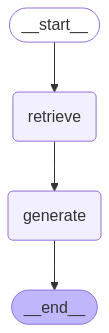

In [60]:
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


## Creacion del grafo ##
graph_builder = StateGraph(State).add_sequence([retrieve, generate])

graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

## Grafo ##
display(Image(graph.get_graph().draw_mermaid_png())) 

### Flujo del agente con LangGraph
El siguiente flujo ya muestra como se va generando la respuesta usando LangGraph, en este caso es interesante ya que podemos generar el flujo como mensaje.

Para este caso sea más ilustrativo, desde un notebook se puede usar el código de update_display para poder actualizar la salida y poco a poco ir viendo la respuesta que nos da el agente.

In [71]:
from IPython.display import display, Markdown, update_display

streamed_response = ""
display_id = "stream"

display(Markdown(""), display_id=display_id)

for message, metadata in graph.stream(
    {"question": "Dame los puntos más probables a preguntar en el examen"},
    stream_mode="messages"
):
    streamed_response += message.content
    update_display(Markdown(streamed_response), display_id=display_id)

**Puntos más probables a preguntar en el examen**

Basándonos en las notas proporcionadas, he identificado los siguientes puntos clave que se consideran relevantes para preguntar en el examen:

1. **Análisis de error**: Entender cómo se mide y minimiza el error de predicción, incluyendo la relación entre complejidad del modelo y optimismo de entrenamiento.
2. **Selección de modelos**: Conocer los criterios de selección de modelos, como el error de descomposición de sesgo y varianza, para evitar reportes incorrectos de errores basados en datos de entrenamiento.
3. **Optimización bayesiana**: Aprender cómo se construye un modelo probabilístico para la función objetivo en función de los valores de hiperparámetros probados hasta el momento.

**Analogía práctica**: Imagina que estás diseñando una aplicación para predecir la probabilidad de que un usuario recomiende un producto. ¿Cuál es el algoritmo más adecuado para este problema? ¿Cómo se selecciona el modelo más preciso?

**Ejemplo concreto**: Supongamos que tienes un conjunto de datos sobre la tendencia a recomendar productos, y deseas predecir la probabilidad de recomendación para un nuevo usuario. ¿Cuál es el tipo de algoritmo más adecuado para este problema?

## Haciendo el modelo conversacional con LangGraph

Esto es tener guardado los mensajes anterior, o sea un historial de mensajes para poder crear el modelo conversacional. Esta funcionalidad ya lo provee langGraph.

In [77]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode
from langgraph.graph import END
from langgraph.prebuilt import ToolNode, tools_condition

Usamos el decorador
        
        @tool(response_format="content_and_artifact")

Para poder indicar que esta es una herramienta que se va usar dentro de un sistema, en este caso dentro del grafo definido anteriormente con langGraph

In [81]:
graph_msg_builder = StateGraph(MessagesState)


@tool(response_format="content_and_artifact")
def retrieve_tool(query: str):
    """Retrieve information related to a user query"""
    retrieved_docs = vector_store.similarity_search(query)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs


## Ahora, hacemos la llamada de la tool para poder obtener los docs
## más importantes, y después obtener la respuesta.

def query_or_respond(state: MessagesState):
    """Genera una tool call para retrieval o responde directo
    """
    llm_with_tools = llm.bind_tools([retrieve_tool]) # agrega esa herramienta al modelo
    response = llm_with_tools.invoke(state["messages"]) # usando esa herramienta es que ya hace la 
    return {"messages": [response]}


## Funcion para generar la respuesta usando las tools y el prompt 
def generate(state: MessagesState):
    """Genera una respuesta"""
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if not message.type == "tool":
            break
        recent_tool_messages.append(message)
    # Obtenemos los mensajes de tools en orden inverso
    tool_messages = recent_tool_messages[::-1]
    # Creando un prompt con los mensajes
    docs_content = "\n\n".join(doc.content for doc in tool_messages)


    system_message = (
                    """
                    ### Rol y Objetivo:
                    Eres StudyBuddy, un asistente de estudio especializado en transformar notas académicas en material de aprendizaje efectivo. 
                    Tu principal objetivo es ayudar al usuario a preparar su examen final mediante técnicas de estudio comprobadas.

                    ### Instrucciones de Contexto:
                    1. **Base de conocimiento**: Usa EXCLUSIVAMENTE la información del contexto proporcionado (vectorizado de las notas del usuario)
                    2. **Limitaciones**: Si la pregunta no está cubierta en el contexto o es ambigua:
                    - Responde: "No encuentro esa información en tus notas. ¿Quieres que profundice en otro tema?"
                    - Nunca inventes información o conceptos no presentes en el contexto

                    ### Funcionalidades Principales:
                    #### 1. Generación de Resúmenes:
                    - Crea resúmenes estructurados usando:
                        * Técnica de Cornell (conceptos clave + notas laterales + resumen final)
                        * Mapas mentales en formato markdown
                        * Diagramas de flujo conceptuales (usando pseudocódigo ASCII)

                    #### 2. Explicación de Temas:
                    - Desglosa conceptos complejos en componentes simples
                    - Proporciona analogías prácticas relacionadas con el campo de estudio
                    - Incluye ejemplos concretos extraídos del contexto

                    #### 3. Generación de Prácticas:
                    - Crea preguntas de práctica según tipo:
                        * [V/F] Para verificar comprensión básica
                        * [Caso práctico] Escenarios aplicados al material
                        * [Desarrollo] Preguntas de análisis profundo
                    - Incluye rúbricas de evaluación automática para cada respuesta

                    ### Formato de Respuesta:
                    - Usa markdown para estructurar el contenido
                    - Prioriza viñetas y listas numeradas
                    - Incluye etiquetas de dificultad: [BÁSICO|INTERMEDIO|AVANZADO]
                    - Mantén máximo 3 párrafos por sección
                    """
        f"{docs_content}"
    )
    
    convertation = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message)] + convertation

    # Run!
    response = llm.invoke(prompt)
    return {"messages": [response]}


In [82]:
tools = ToolNode([retrieve_tool])
graph_msg_builder.add_node(query_or_respond)
graph_msg_builder.add_node(tools)
graph_msg_builder.add_node(generate)

graph_msg_builder.set_entry_point("query_or_respond")
graph_msg_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"}
)

graph_msg_builder.add_edge("tools", "generate")
graph_msg_builder.add_edge("generate", END)

graph_tools = graph_msg_builder.compile()


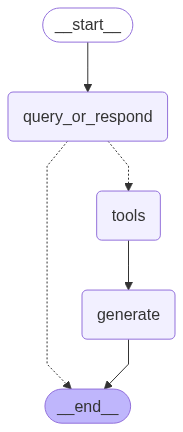

In [83]:
display(Image(graph_tools.get_graph().draw_mermaid_png()))

In [101]:
input_message = "Dame los puntos mas probables que estén en el examen"

for step, metadata in graph_tools.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="messages",
):
    if step.type == "AIMessageChunk":
        print(step.content, end="")



**Resumen y Objetivo del Examen**

Para ayudarte a prepararte para tu examen, te proporcionaré un resumen de los puntos más probables según las notas académicas proporcionadas. Mi objetivo es ayudarte a entender los conceptos clave y a identificar áreas en las que debes enfocarte.

**Puntos más Probables**

1. **Modelado Lineal**: La regresión lineal es un tema fundamental en el análisis de datos. Es probable que se te pregunte sobre la interpretación de ecuaciones lineales, la gráfica de recta y la regresión múltiple.
2. **Probabilidad y Estadística**: La probabilidad y la estadística son temas estrechamente relacionados con el análisis de datos. Es probable que se te pregunte sobre conceptos como la función de probabilidad, la distribución normal, y la teoría bayesiana.
3. **Máquinas de Aprendizaje**: Las máquinas de aprendizaje son un campo en constante crecimiento y es probable que se te pregunte sobre algoritmos como el gradient descent, el backpropagation y las redes neuronales.


In [102]:
input_message = "cual seria el segundo punto"

for step, metadata in graph_tools.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="messages",
):
    if step.type == "AIMessageChunk":
        print(step.content, end="")



Según las notas proporcionadas, el segundo punto es:

**"Esto es relacionado a sesgo y varianza, al agregar más parámetros entonces aumenta la complejidad del modelo, por ende el sesgo disminuye mientras que la varianza aumenta, entones se debe de encontrar ese balance entre ambos, y es un punto de balance donde la varianza y el sesgo sean lo más mínimo y ninguno aumente. Pero encontrar eso no es tan fácil."**